In [1]:
#################### Numerical & Physical Mixing in Ideal ROMS-Budgell Beaufort Jet ########################
# The purpose of this script is to plot time series of volume-averaged numerical and physical 
# mixing for salinity and temperature. Other processing for time series might be added in here, too,
# but all post-processed data will be save to netCDFs so the analysis does not need to be redone 
# to replot things. 
#
# Notes:
# - This script runs in xroms 
# - This script heavily uses code from Dylan Schlichting 
# - Other things that will maybe be added into here: energy analysis of eddy things, 
#   M2 and N2, ice volume/concentration/whatever is standard in papers
# - Choose an area that always has eddies, vertical slices constrained to top 200 m, 
# - I think I am going to add things for ice variables into here...

##############################################################################################################

In [40]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
from matplotlib.lines import Line2D
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions 
Make functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

## Post-Processing  
Load in and process the model output.

In [6]:
# Constant forcing (time series), ice, U3C4, K-eps
path_const_u3c4_keps = glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_gen = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_kkl = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_komega = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc')
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#path_const_u3c4_kpp = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')

In [7]:
# Load in the output from above with xroms
ds, grid = open_mfroms(path_const_u3c4_keps)
add_derivatives(ds, grid)

<xarray.Dataset> Size: 6TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1440)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 190GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 190GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 186GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 185GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 185GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/168)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Thursday - January 1, 2026 -  7:17:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [8]:
print(ds.ocean_time[0:5].values)
print(ds.ocean_time[-5:-1].values)

[cftime.DatetimeProlepticGregorian(1, 1, 1, 1, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 3, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 5, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 7, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 1, 1, 9, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeProlepticGregorian(1, 4, 30, 15, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 17, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 19, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(1, 4, 30, 21, 0, 0, 0, has_year_zero=True)]


## Mixing!  
Calculate mixing in the domain. First pick the region we want to do calculations over.

In [9]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [10]:
print(len(ds.y_rho[:,0]))
print(len(y_rho))

1002
1002


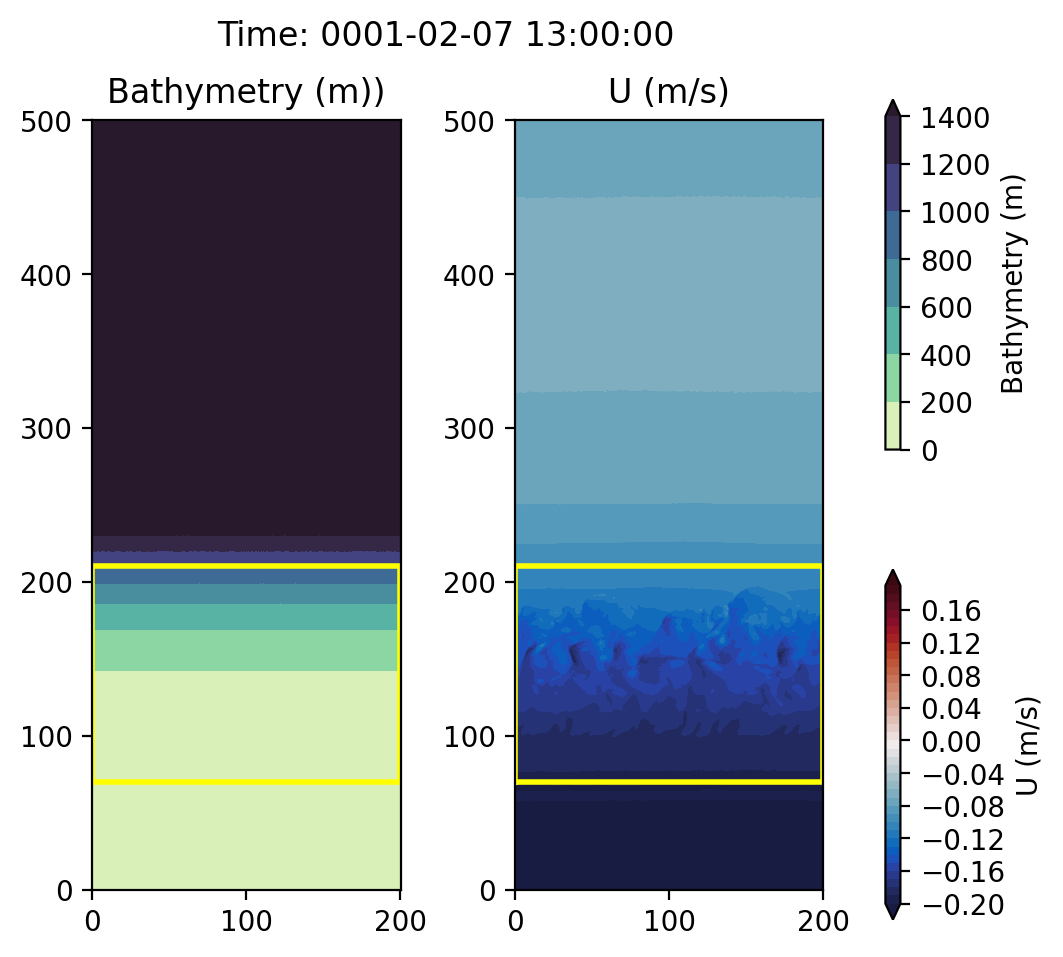

In [11]:
# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds.h, cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()
 

In [12]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0


In [13]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

### Physical & Numerical Mixing  
Calculate mixing in that box and in top 200 m of the water column

In [ ]:
ds.ocean_time[0:5].values

In [ ]:
ds.z_rho[0,:,100,100].values

In [ ]:
# Get physical mixing from the output
# Salinity (2-hourly)
Akr_rho = grid.interp(ds.AKr, 'Z')
mphys = (Akr_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphys.attrs = ''

# Temperature (2-hourly)
Akrt_rho = grid.interp(ds.AKrt, 'Z')
mphyt = (Akrt_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphyt.attrs = ''

In [ ]:
# Get numerical mixing from the output
# Numerical mixing (2-hourly)
mnum_salt_dv = (ds.dye_03*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mnum_temp_dv = (ds.dye_06*ds.dV).isel(eta_rho = eta_slice, xi_rho=xi_slice).where(ds.z_rho>-z_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()

### Save to NetCDF  
Save the post-processed data to a netCDF

In [ ]:
# Save all the 2-hourly data to the same netcdf

# Variables to save: mphys, mphyt, mnum_salt_dv, mnum_temp_dv

roms_phy_num_mix_salt_temp = xr.Dataset(
    data_vars=dict(
        mphys=(['ocean_time'], mphys.values),
        mphyt=(['ocean_time'], mphyt.values),
        mnum_salt_dv=(['ocean_time'], mnum_salt_dv.values),
        mnum_temp_dv=(['ocean_time'], mnum_temp_dv.values)
    ),
    coords=dict(
        ocean_time=('ocean_time', ds.ocean_time.values)
    ),
    attrs=dict(description='Time-series ROMS output including physical and numerical mixing of salinity and temperature from 2-hourly model output; uses /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
)

# Add attributes to the 'temperature' data variable
roms_phy_num_mix_salt_temp['mphys'].attrs['long_name'] = 'Physical mixing of salinity at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphys'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mphyt'].attrs['long_name'] = 'Physical mixing of temperature at 2-hourly intervals'
roms_phy_num_mix_salt_temp['mphyt'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['long_name'] = 'Numerical mixing of salinity at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_salt_dv'].attrs['units'] = '(g/kg)\u00b2(m\u00b3/s))'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['long_name'] = 'Numerical mixing of temperature at 2-hourly interval'
roms_phy_num_mix_salt_temp['mnum_temp_dv'].attrs['units'] = '(C)\u00b2(m\u00b3/s))'

# Save to a netcdf
# Run with ice (change name based on the run being analyzed)
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_gen_001.nc')
# Run without ice
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')


## Plot Mixing  
Plot timeseries of the mixing to compare 

In [14]:
# If post-processed data is ready, load it in
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
roms_phy_num_mix_u3c4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_keps_001.nc')

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
roms_phy_num_mix_u3c4_keps_no_ice = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_phy_num_mix_salt_temp_2hr_500m_const_forc_no_ice_u3c4_keps_001.nc')

# Constant forcing, U3C4, gen
roms_phy_num_mix_u3c4_gen = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_gen_002.nc')

# Constant forcing, U3C4, kkl
roms_phy_num_mix_u3c4_kkl = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_kkl_001.nc')

# Constant forcing, U3C4, k-omega
roms_phy_num_mix_u3c4_komega = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3c4_komega_001.nc')

# Constant forcing, U3C4, kpp
roms_phy_num_mix_u3c4_kpp = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_phy_num_mix_salt_temp_2hr_500m_const_forc_u3c4_kpp_002.nc')

# Constant forcing, akima, k-epsilon
roms_phy_num_mix_akima_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_akima_keps_001.nc')

# Constant forcing, HSIMT, k-epsilon
roms_phy_num_mix_hsimt_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_hsimt_keps_001.nc')

# Constant forcing, MPDATA, k-epsilon
roms_phy_num_mix_mpdata_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_mpdata_keps_001.nc')

# Constant forcing, u3splitc4, k-epsilon
roms_phy_num_mix_u3splitc4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_phy_num_mix_salt_temp_2hr_ice_500m_const_forc_u3splitc4_keps_001.nc')



In [15]:
# Make a time for each output
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
time_tmp = roms_phy_num_mix_u3c4_keps['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
time_tmp = roms_phy_num_mix_u3c4_keps_no_ice['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_keps_no_ice = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, gen
time_tmp = roms_phy_num_mix_u3c4_gen['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_gen = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kkl
time_tmp = roms_phy_num_mix_u3c4_kkl['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_kkl = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, k-omega
time_tmp = roms_phy_num_mix_u3c4_komega['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_komega = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kpp
time_tmp = roms_phy_num_mix_u3c4_kpp['ocean_time']
t0 = time_tmp.values[0]
time_u3c4_kpp = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, akima, k-epsilon
time_tmp = roms_phy_num_mix_akima_keps['ocean_time']
t0 = time_tmp.values[0]
time_akima_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, HSIMT, k-epsilon
time_tmp = roms_phy_num_mix_hsimt_keps['ocean_time']
t0 = time_tmp.values[0]
time_hsimt_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, MPDATA, k-epsilon
time_tmp = roms_phy_num_mix_mpdata_keps['ocean_time']
t0 = time_tmp.values[0]
time_mpdata_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, u3splitc4, k-epsilon
time_tmp = roms_phy_num_mix_u3splitc4_keps['ocean_time']
t0 = time_tmp.values[0]
time_u3splitc4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Make time array to use for plotting 
# # Time vector
# # I think do some stuff to get a vector of time for plotting?
# time = ds['ocean_time']
# t0 = time.values[0]

# time = np.array([
#     (t - t0).total_seconds() / 86400
#     for t in time.values
# ])

In [ ]:
# Re-assign the data from the post-processed data to work 
# with the plots below 
# Run with ice
# mphys_ice = roms_phy_num_mix_u3c4_keps.mphys
# mphyt_ice = roms_phy_num_mix_u3c4_keps.mphyt
# mnum_salt_dv_ice = roms_phy_num_mix_u3c4_keps.mnum_salt_dv
# mnum_temp_dv_ice = roms_phy_num_mix_u3c4_keps.mnum_temp_dv


# # Run without ice 
# mphys_no_ice = roms_phy_num_mix_no_ice.mphys
# mphyt_no_ice = roms_phy_num_mix_no_ice.mphyt
# mnum_salt_dv_no_ice = roms_phy_num_mix_no_ice.mnum_salt_dv
# mnum_temp_dv_no_ice = roms_phy_num_mix_no_ice.mnum_temp_dv


In [ ]:
# Plot these comparisons 
# Compare phsyical and numerical mixing of salinity and temperature for the
# 2-hourly run
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
ax[0].plot(time, mphys_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time, mnum_salt_dv_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt}$')
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
ax[1].plot(time, mphyt_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time, mnum_temp_dv_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp}$')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_500m_const_forc_u3c4_keps_001.png')

In [ ]:
# Eventually come back and do a plot that compares
# the run with ice to the run without ice (and other 
# runs later/eventually, too)

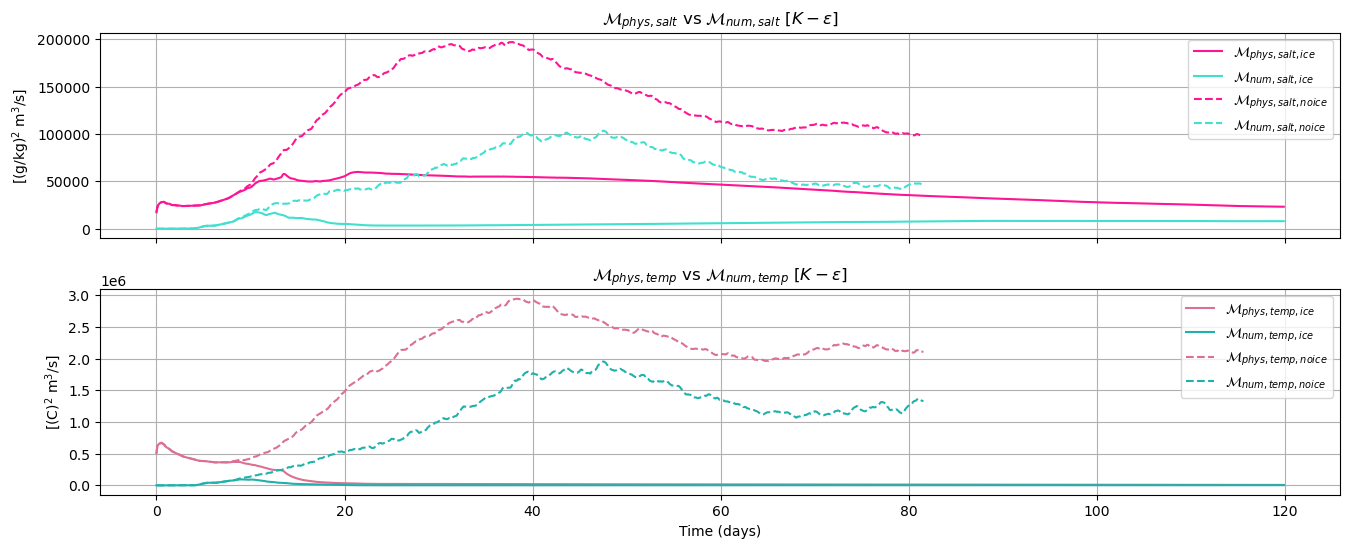

In [16]:
# Make a plot comparing run with ice to run witout ice
# Be sure to only compare the overlapping times 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,salt,ice}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,salt,ice}$')
# No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$ [$K-\epsilon$]')

# Plot physical and numerical mixing of temperature 
# Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,ice}$')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,ice}$')
# No ice
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
#ax[1].plot(ds.ocean_time, mphyt_off, color='k', label=r'$\mathcal{M}_{phys,temp,off}$')
ax[1].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$ [$K-\epsilon$]')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

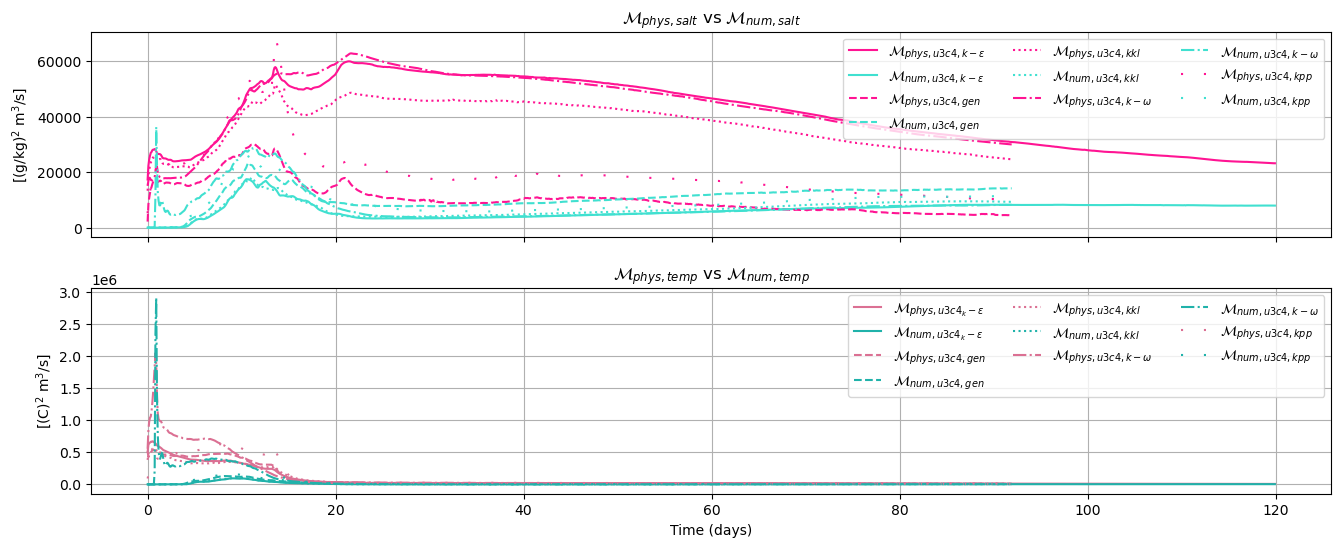

In [17]:
# Make a plot comparing the different vertical mixing schemes 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[0].plot(time, mphys_no_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
# #ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
# ax[0].plot(time, mnum_salt_dv_no_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,gen}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,kkl}$', linestyle=':')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle=':')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$', linestyle='-.')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='-.')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,kpp}$', linestyle=(0, (1, 10)))
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle=(0, (1, 10)))


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4_k-\epsilon}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4_k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[1].plot(time, mphyt_no_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
# ax[1].plot(time, mnum_temp_dv_no_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,gen}$', linestyle='--')
ax[1].plot(time_u3c4_gen, roms_phy_num_mix_u3c4_gen.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,kkl}$', linestyle=':')
ax[1].plot(time_u3c4_kkl, roms_phy_num_mix_u3c4_kkl.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle=':')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$', linestyle='-.')
ax[1].plot(time_u3c4_komega, roms_phy_num_mix_u3c4_komega.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='-.')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4,kpp}$', linestyle=(0, (1, 10)))
ax[1].plot(time_u3c4_kpp, roms_phy_num_mix_u3c4_kpp.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle=(0, (1, 10)))


# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend(ncols=3)
ax[0].set_xticklabels('')
ax[1].legend(ncols=3)
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

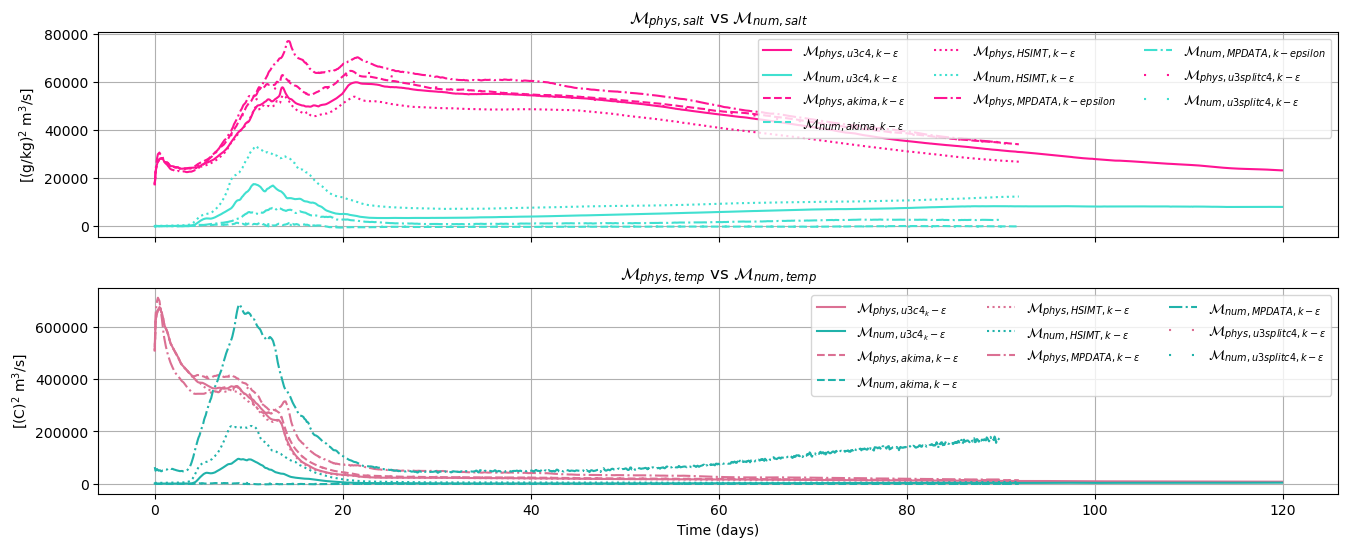

In [18]:
# Do this again but for horizontal advection schemes 
# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[0].plot(time, mphys_no_ice, color='deeppink', label=r'$\mathcal{M}_{phys,salt,no ice}$', linestyle='--')
# #ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
# ax[0].plot(time, mnum_salt_dv_no_ice, color='turquoise', label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# akima k-epsilon
ax[0].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$', linestyle='--')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[0].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$', linestyle=':')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
ax[0].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$', linestyle='-.')
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='-.')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mphys, color='deeppink', label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))
#ax[0].plot(ds.ocean_time, mphys_off, color='k', label=r'$\mathcal{M}_{phys,salt,off}$')
ax[0].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv, color='turquoise', label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3c4_k-\epsilon}$')
ax[1].plot(time_u3c4_keps, roms_phy_num_mix_u3c4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3c4_k-\epsilon}$')
# U3C4 K-epsilon No ice
# ax[1].plot(time, mphyt_no_ice, color='palevioletred', label=r'$\mathcal{M}_{phys,temp,no ice}$', linestyle='--')
# ax[1].plot(time, mnum_temp_dv_no_ice, color='lightseagreen', label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# akima k-epsilon
ax[1].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$', linestyle='--')
ax[1].plot(time_akima_keps, roms_phy_num_mix_akima_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[1].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$', linestyle=':')
ax[1].plot(time_hsimt_keps, roms_phy_num_mix_hsimt_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle=':')
# mpdata k-epsilon
ax[1].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,MPDATA,k-\epsilon}$', linestyle='-.')
ax[1].plot(time_mpdata_keps, roms_phy_num_mix_mpdata_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,MPDATA,k-\epsilon}$', linestyle='-.')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mphyt, color='palevioletred', label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))
ax[1].plot(time_u3splitc4_keps, roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv, color='lightseagreen', label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle=(0, (1, 10)))


# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
ax[0].legend(ncols=3)
ax[0].set_xticklabels('')
ax[1].legend(ncols=3)
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

In [19]:
# Make colors to use
mixing_colors_all = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#7f7f7f']

In [20]:
len(time_u3c4_keps_no_ice)

980

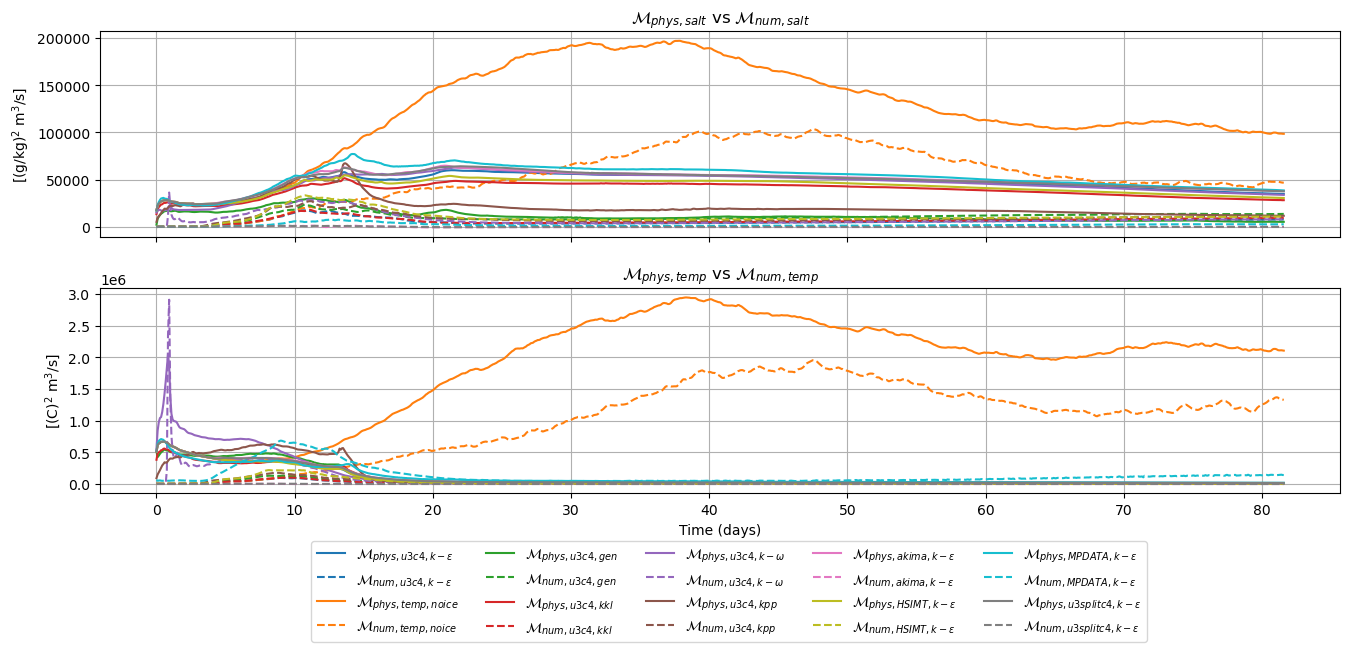

In [21]:
# Make giant plot comparing all of them

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')


# 
# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,temp,no ice}$', linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-\epsilon}$')
ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-\epsilon}$', linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')



# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].legend(ncols=5, bbox_to_anchor=(0.85, -0.2))
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

In [ ]:
# OR can combine the above ones as different panelsssss

In [ ]:
# Prep the sea ice data for all the runs 


## Sea Ice Stuff  
Do some processing of ice things and plot them here, too

In [22]:
# Load in runs for sea ice analysis 

# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps_no_ice = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_no_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, U3C4, gen
ds_ice_u3c4_gen = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
ds_ice_u3c4_kkl = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
ds_ice_u3c4_komega = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc')
# Constant forcing, U3C4, kpp
ds_ice_u3c4_kpp = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')
# Constant forcing, akima, k-epsilon
ds_ice_akima_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_akima_keps_*.nc')
# Constant forcing, HSIMT, k-epsilon
ds_ice_hsimt_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_HSIMT_keps_*.nc')
# Constant forcing, MPDATA, k-epsilon
ds_ice_mpdata_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_mpdata_keps_*.nc')
# Constant forcing, u3splitc4, k-epsilon
ds_ice_u3splitc4_keps = xr.open_mfdataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3splitc4_keps_*.nc')


In [23]:
# Make time for each run
time_u3c4_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_keps.ocean_time.values])
time_u3c4_keps_no_ice = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_keps_no_ice.ocean_time.values])
time_u3c4_gen = np.array([(t - ds_ice_u3c4_gen.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_gen.ocean_time.values])
time_u3c4_kkl = np.array([(t - ds_ice_u3c4_kkl.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_kkl.ocean_time.values])
time_u3c4_komega = np.array([(t - ds_ice_u3c4_komega.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_komega.ocean_time.values])
time_u3c4_kpp = np.array([(t - ds_ice_u3c4_kpp.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3c4_kpp.ocean_time.values])
time_akima_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_akima_keps.ocean_time.values])
time_hsimt_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_hsimt_keps.ocean_time.values])
time_mpdata_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_mpdata_keps.ocean_time.values])
time_u3splitc4_keps = np.array([(t - ds_ice_u3c4_keps.ocean_time[0].values).total_seconds() / 86400 for t in ds_ice_u3splitc4_keps.ocean_time.values])

In [24]:
# Assign a color to each run
#run_colors = ['blue', 'mediumspringgreen', 'lightseagreen', 'darkviolet', 'mediumpurple']
run_colors = ['blue', 'mediumspringgreen', 'orange', 'darkviolet', 'red']
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [25]:
# Calculate time series of...
# total ice volume, 

In [26]:
# Apparently (varinfo.yaml) ice_thickness is the average 
# ice thickness in a cell so assuming that is true, multiply
# by cell area to get volume
# Assuming the grid is same resolution everywhere, get area
cell_area = dx * dy

# Now get volume
ice_vol_u3c4_keps = ds_ice_u3c4_keps.ice_thickness*cell_area
ice_vol_u3c4_gen = ds_ice_u3c4_gen.ice_thickness*cell_area
ice_vol_u3c4_kkl = ds_ice_u3c4_kkl.ice_thickness*cell_area
ice_vol_u3c4_komega = ds_ice_u3c4_komega.ice_thickness*cell_area
ice_vol_u3c4_kpp = ds_ice_u3c4_kpp.ice_thickness*cell_area
ice_vol_akima_keps = ds_ice_akima_keps.ice_thickness*cell_area
ice_vol_hsimt_keps = ds_ice_hsimt_keps.ice_thickness*cell_area
ice_vol_mpdata_keps = ds_ice_mpdata_keps.ice_thickness*cell_area
ice_vol_u3splitc4_keps = ds_ice_u3splitc4_keps.ice_thickness*cell_area

In [27]:
# Take the total over the region of interest indicated above
# Trim to this region
ice_vol_u3c4_keps_reg1 = ice_vol_u3c4_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_gen_reg1 = ice_vol_u3c4_gen.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_kkl_reg1 = ice_vol_u3c4_kkl.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_komega_reg1 = ice_vol_u3c4_komega.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3c4_kpp_reg1 = ice_vol_u3c4_kpp.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_akima_keps_reg1 = ice_vol_akima_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_hsimt_keps_reg1 = ice_vol_hsimt_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_mpdata_keps_reg1 = ice_vol_mpdata_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_vol_u3splitc4_keps_reg1 = ice_vol_u3splitc4_keps.isel(eta_rho = eta_slice, xi_rho = xi_slice)
print(np.shape(ice_vol_u3c4_keps_reg1))

# Now sum over this region to get total ice volume 
ice_vol_u3c4_keps_reg1_tot = ice_vol_u3c4_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_gen_reg1_tot = ice_vol_u3c4_gen_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_kkl_reg1_tot = ice_vol_u3c4_kkl_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_komega_reg1_tot = ice_vol_u3c4_komega_reg1.sum(axis=(1,2)).compute()
ice_vol_u3c4_kpp_reg1_tot = ice_vol_u3c4_kpp_reg1.sum(axis=(1,2)).compute()
ice_vol_akima_keps_reg1_tot = ice_vol_akima_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_hsimt_keps_reg1_tot = ice_vol_hsimt_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_mpdata_keps_reg1_tot = ice_vol_mpdata_keps_reg1.sum(axis=(1,2)).compute()
ice_vol_u3splitc4_keps_reg1_tot = ice_vol_u3splitc4_keps_reg1.sum(axis=(1,2)).compute()

(1440, 280, 398)


(0.1, 100000000000.0)

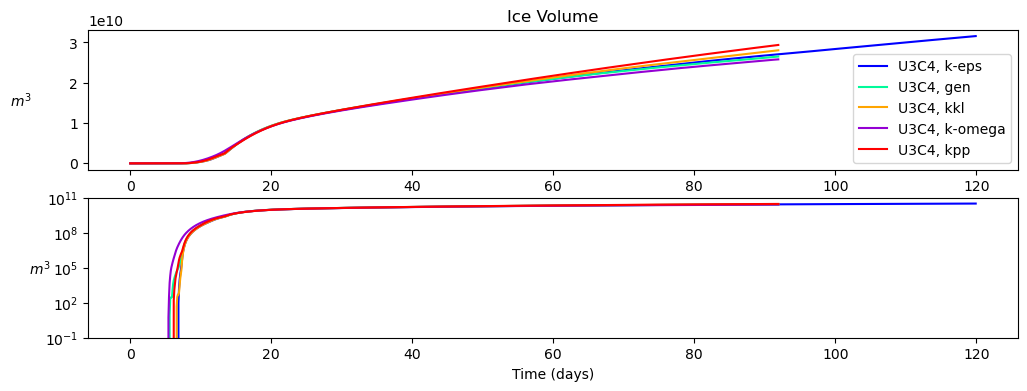

In [28]:
# Plot time series of ice volume 
fig, ax = plt.subplots(2, figsize=(12,4))

# Plot ice volume - linear y-axis
ax[0].plot(time_u3c4_keps, ice_vol_u3c4_keps_reg1_tot, color=run_colors[0], label=r'U3C4, k-eps')
ax[0].plot(time_u3c4_gen, ice_vol_u3c4_gen_reg1_tot, color=run_colors[1], label=r'U3C4, gen')
ax[0].plot(time_u3c4_kkl, ice_vol_u3c4_kkl_reg1_tot, color=run_colors[2], label=r'U3C4, kkl')
ax[0].plot(time_u3c4_komega, ice_vol_u3c4_komega_reg1_tot, color=run_colors[3], label=r'U3C4, k-omega')
ax[0].plot(time_u3c4_kpp, ice_vol_u3c4_kpp_reg1_tot, color=run_colors[4], label=r'U3C4, kpp')

# Plot ice volume - log y-axis
ax[1].plot(time_u3c4_keps, ice_vol_u3c4_keps_reg1_tot, color=run_colors[0], label=r'U3C4, k-eps')
ax[1].plot(time_u3c4_gen, ice_vol_u3c4_gen_reg1_tot, color=run_colors[1], label=r'U3C4, gen')
ax[1].plot(time_u3c4_kkl, ice_vol_u3c4_kkl_reg1_tot, color=run_colors[2], label=r'U3C4, kkl')
ax[1].plot(time_u3c4_komega, ice_vol_u3c4_komega_reg1_tot, color=run_colors[3], label=r'U3C4, k-omega')
ax[1].plot(time_u3c4_kpp, ice_vol_u3c4_kpp_reg1_tot, color=run_colors[4], label=r'U3C4, kpp')


# Label the axes
ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel('$m^{3}$', rotation=0, va='center', labelpad=35)
ax[1].set_ylabel('$m^{3}$', rotation=0, va='center')
ax[0].set_title(r'Ice Volume')

ax[0].legend()

ax[1].semilogy()
ax[1].set_ylim(1e-1, 1e11)
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/ice_vol_reg1_ice_500m_const_forc_u3c4_keps_001.png')


In [29]:
# Calculte average ice concentration in this region
# Get the part in this region
ice_conc_u3c4_keps_reg1 = ds_ice_u3c4_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_gen_reg1 = ds_ice_u3c4_gen.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_kkl_reg1 = ds_ice_u3c4_kkl.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_komega_reg1 = ds_ice_u3c4_komega.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3c4_kpp_reg1 = ds_ice_u3c4_kpp.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_akima_keps_reg1 = ds_ice_akima_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_hsimt_keps_reg1 = ds_ice_hsimt_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_mpdata_keps_reg1 = ds_ice_mpdata_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)
ice_conc_u3splitc4_keps_reg1 = ds_ice_u3splitc4_keps.Aice.isel(eta_rho = eta_slice, xi_rho = xi_slice)

# Take the average over space 
ice_conc_u3c4_keps_reg1_avg = ice_conc_u3c4_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_gen_reg1_avg = ice_conc_u3c4_gen_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_kkl_reg1_avg = ice_conc_u3c4_kkl_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_komega_reg1_avg = ice_conc_u3c4_komega_reg1.mean(axis=(1,2)).compute()
ice_conc_u3c4_kpp_reg1_avg = ice_conc_u3c4_kpp_reg1.mean(axis=(1,2)).compute()
ice_conc_akima_keps_reg1_avg = ice_conc_akima_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_hsimt_keps_reg1_avg = ice_conc_hsimt_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_mpdata_keps_reg1_avg = ice_conc_mpdata_keps_reg1.mean(axis=(1,2)).compute()
ice_conc_u3splitc4_keps_reg1_avg = ice_conc_u3splitc4_keps_reg1.mean(axis=(1,2)).compute()

In [ ]:
# Save ice things to netCDFs since they take a little 
# while to calculate
roms_ice_vol_conc = xr.Dataset(
    data_vars=dict(
        ice_vol_u3c4_keps_tot=(['ocean_time'], ice_vol_u3c4_keps_reg1_tot[:980].values),
        ice_vol_u3c4_gen_tot=(['ocean_time'], ice_vol_u3c4_gen_reg1_tot[:980].values),
        ice_vol_u3c4_kkl_tot=(['ocean_time'], ice_vol_u3c4_kkl_reg1_tot[:980].values),
        ice_vol_u3c4_komega_tot=(['ocean_time'], ice_vol_u3c4_komega_reg1_tot[:980].values),
        ice_vol_u3c4_kpp_tot=(['ocean_time'], ice_vol_u3c4_kpp_reg1_tot[:980].values),
        ice_vol_akima_keps_tot=(['ocean_time'], ice_vol_akima_keps_reg1_tot[:980].values),
        ice_vol_hsimt_keps_tot=(['ocean_time'], ice_vol_hsimt_keps_reg1_tot[:980].values),
        ice_vol_mpdata_keps_tot=(['ocean_time'], ice_vol_mpdata_keps_reg1_tot[:980].values),
        ice_vol_u3splitc4_keps_tot=(['ocean_time'], ice_vol_u3splitc4_keps_reg1_tot[:980].values),
        ice_conc_u3c4_keps_avg=(['ocean_time'], ice_conc_u3c4_keps_reg1_avg[:980].values),
        ice_conc_u3c4_gen_avg=(['ocean_time'], ice_conc_u3c4_gen_reg1_avg[:980].values),
        ice_conc_u3c4_kkl_avg=(['ocean_time'], ice_conc_u3c4_kkl_reg1_avg[:980].values),
        ice_conc_u3c4_komega_avg=(['ocean_time'], ice_conc_u3c4_komega_reg1_avg[:980].values),
        ice_conc_u3c4_kpp_avg=(['ocean_time'], ice_conc_u3c4_kpp_reg1_avg[:980].values),
        ice_conc_akima_keps_avg=(['ocean_time'], ice_conc_akima_keps_reg1_avg[:980].values),
        ice_conc_hsimt_keps_avg=(['ocean_time'], ice_conc_hsimt_keps_reg1_avg[:980].values),
        ice_conc_mpdata_keps_avg=(['ocean_time'], ice_conc_mpdata_keps_reg1_avg[:980].values),
        ice_conc_u3splitc4_keps_avg=(['ocean_time'], ice_conc_u3splitc4_keps_reg1_avg[:980].values),
    ),
    coords=dict(
        ocean_time=('ocean_time', time_u3c4_keps[:980])
    ),
    attrs=dict(description='Time-series of total ice volume and average ice concentration of ROMS output from 2-hourly model output for all runs; values are for boxed region used for all analyses')
)

# Add attributes to the 'temperature' data variable
# Ice volume 
roms_ice_vol_conc['ice_vol_u3c4_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, k-epsilon'
roms_ice_vol_conc['ice_vol_u3c4_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_gen_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, gen'
roms_ice_vol_conc['ice_vol_u3c4_gen_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_kkl_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, kkl'
roms_ice_vol_conc['ice_vol_u3c4_kkl_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_komega_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, k-omega'
roms_ice_vol_conc['ice_vol_u3c4_komega_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3c4_kpp_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3C4, kpp'
roms_ice_vol_conc['ice_vol_u3c4_kpp_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_akima_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, akima, k-epsilon'
roms_ice_vol_conc['ice_vol_akima_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_hsimt_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, HSIMT, k-epsilon'
roms_ice_vol_conc['ice_vol_hsimt_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_mpdata_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, MPDATA, k-epsilon'
roms_ice_vol_conc['ice_vol_mpdata_keps_tot'].attrs['units'] = '$m^{3}$'
roms_ice_vol_conc['ice_vol_u3splitc4_keps_tot'].attrs['long_name'] = 'Total ice volume in box 1 in run with constant forcing, U3splitC4, k-epsilon'
roms_ice_vol_conc['ice_vol_u3splitc4_keps_tot'].attrs['units'] = '$m^{3}$'
# Ice concentration 
roms_ice_vol_conc['ice_conc_u3c4_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, k-epsilon'
roms_ice_vol_conc['ice_conc_u3c4_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_gen_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, gen'
roms_ice_vol_conc['ice_conc_u3c4_gen_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_kkl_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, kkl'
roms_ice_vol_conc['ice_conc_u3c4_kkl_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_komega_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, k-omega'
roms_ice_vol_conc['ice_conc_u3c4_komega_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3c4_kpp_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3C4, kpp'
roms_ice_vol_conc['ice_conc_u3c4_kpp_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_akima_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, akima, k-epsilon'
roms_ice_vol_conc['ice_conc_akima_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_hsimt_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, HSIMT, k-epsilon'
roms_ice_vol_conc['ice_conc_hsimt_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_mpdata_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, MPDATA, k-epsilon'
roms_ice_vol_conc['ice_conc_mpdata_keps_avg'].attrs['units'] = 'fraction'
roms_ice_vol_conc['ice_conc_u3splitc4_keps_avg'].attrs['long_name'] = 'Average ice concentration in box 1 in run with constant forcing, U3splitC4, k-epsilon'
roms_ice_vol_conc['ice_conc_u3splitc4_keps_avg'].attrs['units'] = 'fraction'



# Save to a netcdf
# All runs
#roms_ice_vol_conc.to_netcdf('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_ice_vol_conc_2hr_ice_all_runs_001.nc')


In [ ]:
# Could make all of this ice analysis a function at some point....
# buttt that's okay for now

In [ ]:
# Plot time series of ice volume 
fig, ax = plt.subplots(figsize=(12,4))

# Plot ice volume
ax.plot(time_u3c4_keps, ice_conc_u3c4_keps_reg1_avg, color=run_colors[0], label=r'U3C4, k-eps')
ax.plot(time_u3c4_gen, ice_conc_u3c4_gen_reg1_avg, color=run_colors[1], label=r'U3C4, gen')
ax.plot(time_u3c4_kkl, ice_conc_u3c4_kkl_reg1_avg, color=run_colors[2], label=r'U3C4, kkl')
ax.plot(time_u3c4_komega, ice_conc_u3c4_komega_reg1_avg, color=run_colors[3], label=r'U3C4, k-omega')
ax.plot(time_u3c4_kpp, ice_conc_u3c4_kpp_reg1_avg, color=run_colors[4], label=r'U3C4, kpp')

# Label the axes
ax.set_xlabel('Time (days)')
ax.set_ylabel('Fraction', rotation=0, va='center', labelpad=35)
ax.set_title(r'Spatially-Averaged Ice Concentration in Box')

ax.legend()

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/avg_ice_conc_reg1_ice_500m_const_forc_u3c4_keps_001.png')

In [ ]:
# Plot combined time series of mixing things and ice volume (maybe?) 


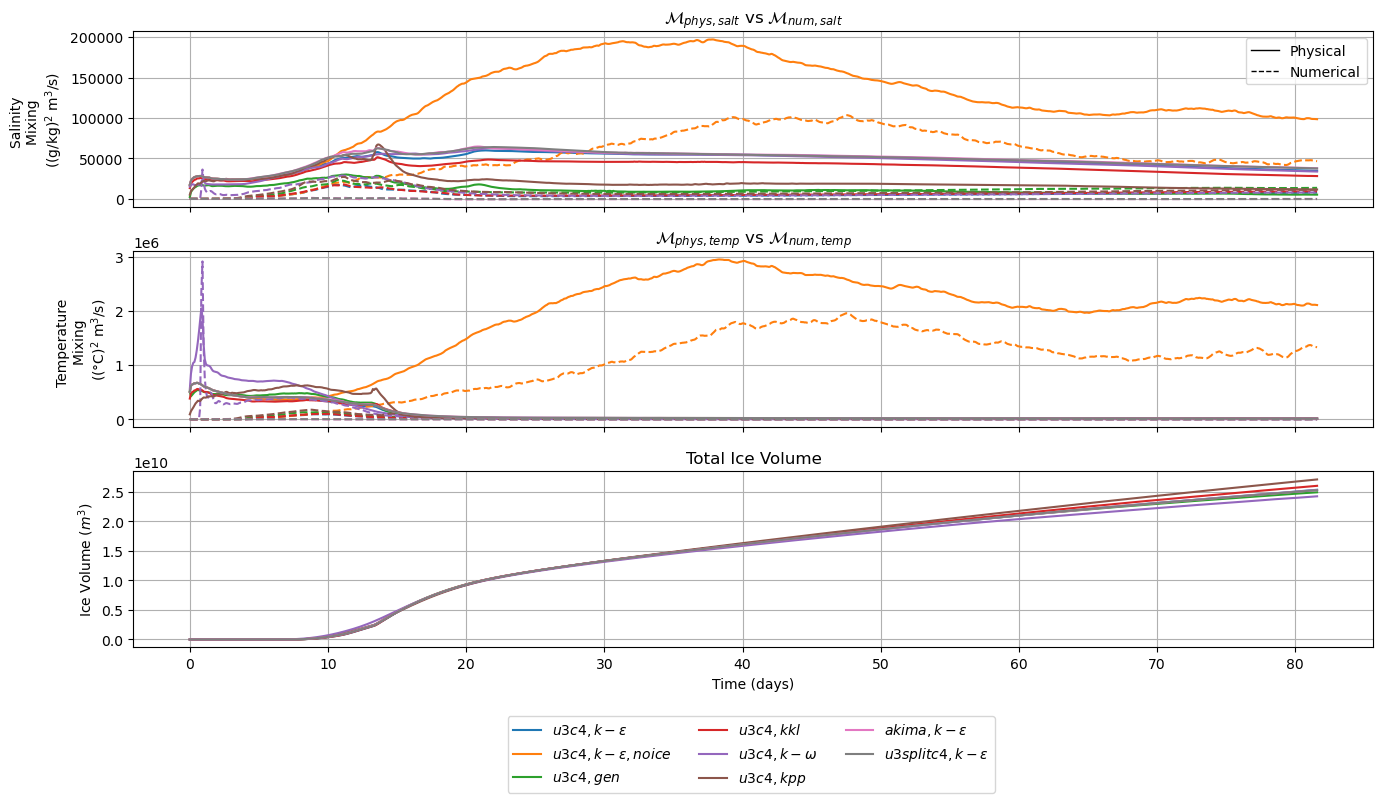

In [48]:
# Make same plot as above (maybe) but add on sea ice timing things 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(3, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], ice_vol_u3c4_gen_reg1_tot[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], ice_vol_u3c4_kkl_reg1_tot[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], ice_vol_u3c4_komega_reg1_tot[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], ice_vol_u3c4_kpp_reg1_tot[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], ice_vol_akima_keps_reg1_tot[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], ice_vol_hsimt_keps_reg1_tot[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], ice_vol_mpdata_keps_reg1_tot[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], ice_vol_u3splitc4_keps_reg1_tot[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Ice Volume ($m^{3}$)')
ax[2].set_title(r'Total Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -1.6))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

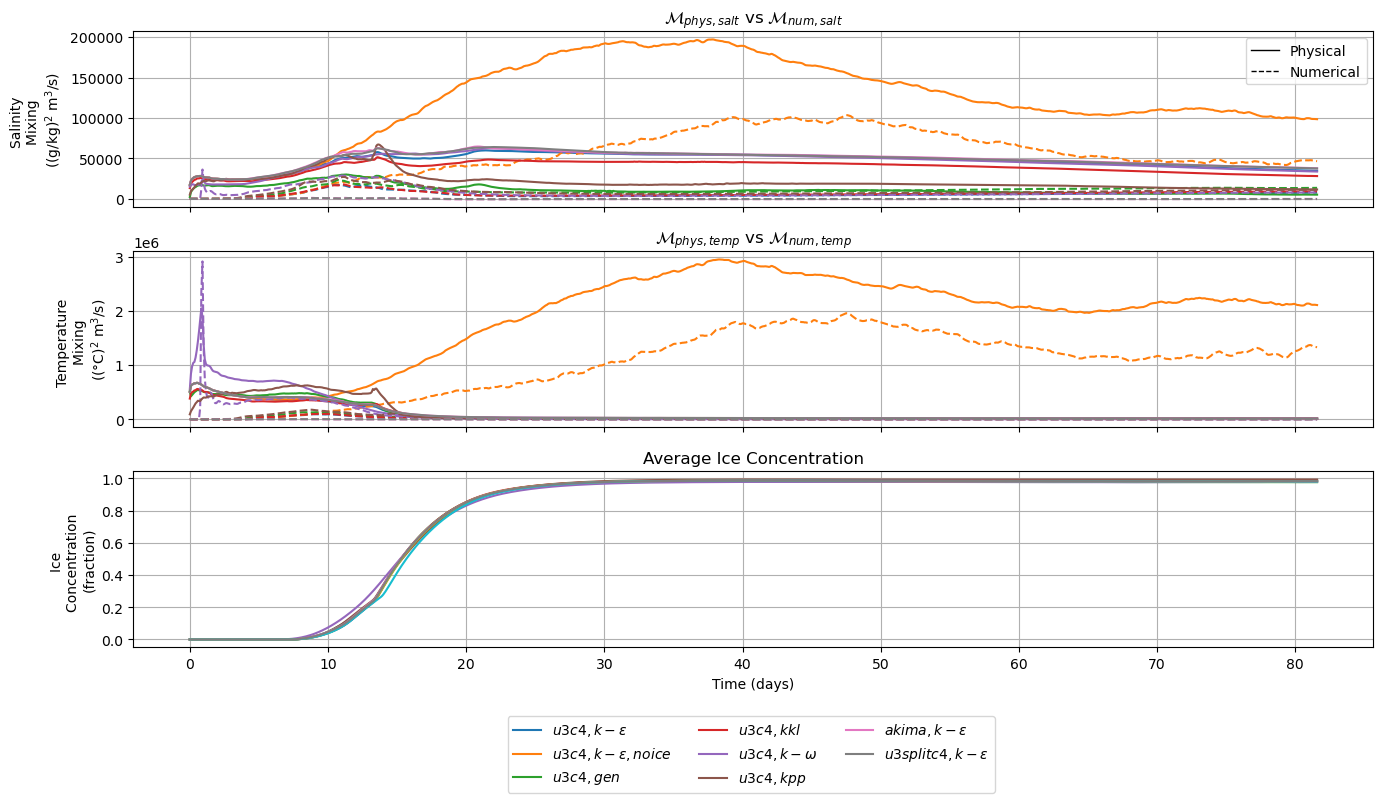

In [49]:
# Make same plot but with average ice concentration instead

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(3, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], ice_conc_u3c4_keps_reg1_avg[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], ice_conc_u3c4_gen_reg1_avg[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], ice_conc_u3c4_kkl_reg1_avg[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], ice_conc_u3c4_komega_reg1_avg[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], ice_conc_u3c4_kpp_reg1_avg[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], ice_conc_akima_keps_reg1_avg[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
ax[2].plot(time_hsimt_keps[:980], ice_conc_hsimt_keps_reg1_avg[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
ax[2].plot(time_mpdata_keps[:980], ice_conc_mpdata_keps_reg1_avg[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], ice_conc_u3splitc4_keps_reg1_avg[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Ice \nConcentration \n(fraction)')
ax[2].set_title(r'Average Ice Concentration')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -1.6))
ax[0].grid()
ax[1].grid()
ax[2].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

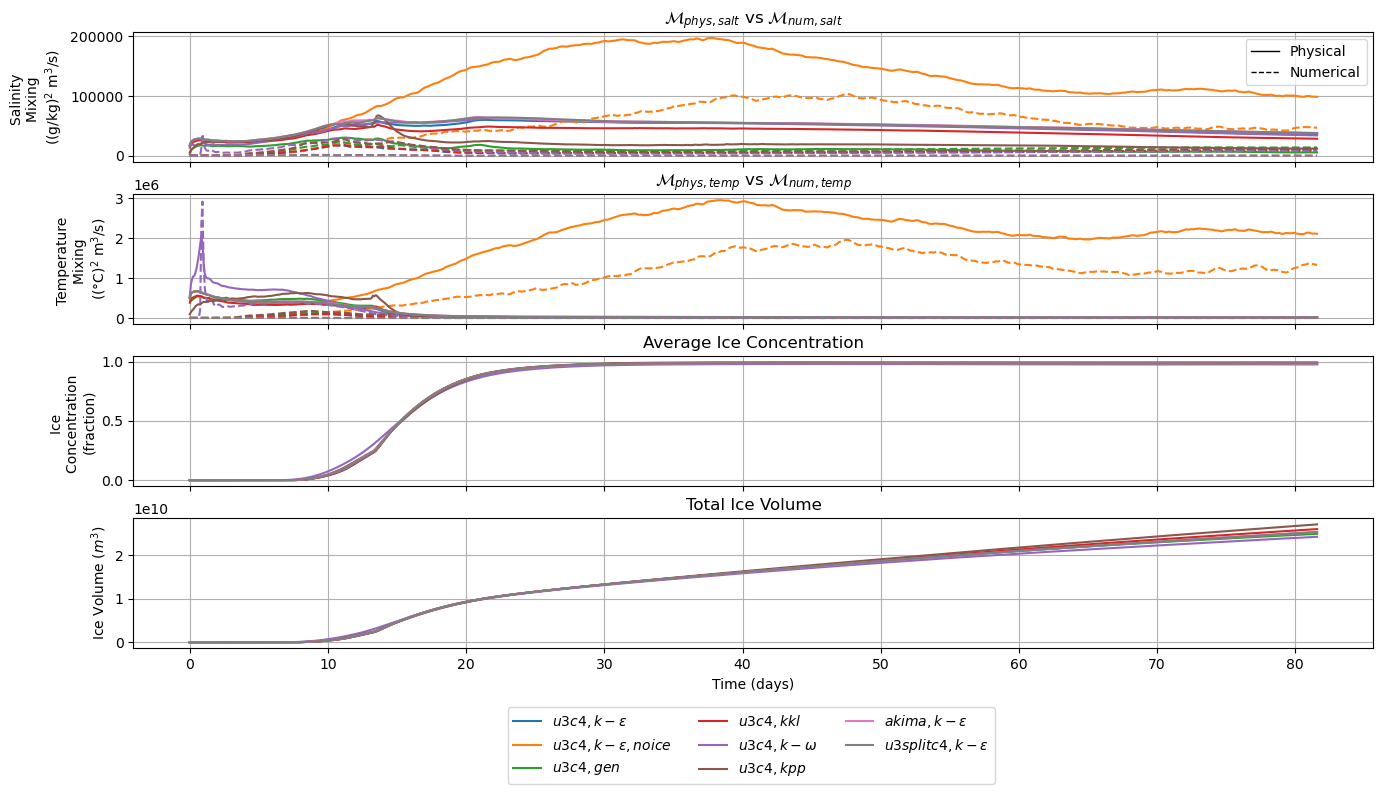

In [57]:
# Make same plot with both ice variables 

# Compare phsyical and numerical mixing of salinity and temperature 
# colors I love: deeppink, palevioletred, turquoise, palevioletred
fig, ax = plt.subplots(4, figsize=(16,8))

# Plot physical and numerical mixing of salinity 
# ---Vertical Mixing schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphys[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{phys,u3c4,k-\epsilon}$')
ax[0].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_salt_dv[:980], color=mixing_colors_all[0], label=r'$\mathcal{M}_{num,u3c4,k-\epsilon}$', linestyle='--')
# U3C4 K-epsilon No ice
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mphys, color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,salt,no ice}$')
ax[0].plot(time_u3c4_keps_no_ice, roms_phy_num_mix_u3c4_keps_no_ice.mnum_salt_dv, color=mixing_colors_all[1], label=r'$\mathcal{M}_{num,salt,no ice}$', linestyle='--')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphys[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{phys,u3c4,gen}$')
ax[0].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_salt_dv[:980], color=mixing_colors_all[2], label=r'$\mathcal{M}_{num,u3c4,gen}$', linestyle='--')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphys[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{phys,u3c4,kkl}$')
ax[0].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_salt_dv[:980], color=mixing_colors_all[3], label=r'$\mathcal{M}_{num,u3c4,kkl}$', linestyle='--')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphys[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{phys,u3c4,k-\omega}$')
ax[0].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_salt_dv[:980], color=mixing_colors_all[4], label=r'$\mathcal{M}_{num,u3c4,k-\omega}$', linestyle='--')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphys[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{phys,u3c4,kpp}$')
ax[0].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_salt_dv[:980], color=mixing_colors_all[5], label=r'$\mathcal{M}_{num,u3c4,kpp}$', linestyle='--')
# --- Horizontal advetion schemes ---
# Plot physical and numerical mixing of salinity 
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphys[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{phys,akima,k-\epsilon}$')
ax[0].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_salt_dv[:980], color=mixing_colors_all[6], label=r'$\mathcal{M}_{num,akima,k-\epsilon}$', linestyle='--')
# hsimt k-epsilon
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphys[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{phys,HSIMT,k-\epsilon}$')
#ax[0].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_salt_dv[:980], color=mixing_colors_all[7], label=r'$\mathcal{M}_{num,HSIMT,k-\epsilon}$', linestyle='--')
# mpdata k-epsilon
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphys[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{phys,MPDATA,k-epsilon}$')
#ax[0].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_salt_dv[:980], color=mixing_colors_all[8], label=r'$\mathcal{M}_{num,MPDATA,k-epsilon}$', linestyle='--')
# u3splitc4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphys[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{phys,u3splitc4,k-\epsilon}$')
ax[0].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_salt_dv[:980], color=mixing_colors_all[9], label=r'$\mathcal{M}_{num,u3splitc4,k-\epsilon}$', linestyle='--')

# Label plot
# ax[0].set_xlabel('Time')
ax[0].set_ylabel('Salinity \nMixing \n((g/kg)$^2$ m$^3$/s)')
ax[0].set_title(r'$\mathcal{M}_{phys,salt}$ vs $\mathcal{M}_{num,salt}$')

# Plot physical and numerical mixing of temperature 
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mphyt[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
ax[1].plot(time_u3c4_keps[:980], roms_phy_num_mix_u3c4_keps.mnum_temp_dv[:980], color=mixing_colors_all[0], linestyle='--')
# U3C4 K-epsilon No ice
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mphyt[:980], color=mixing_colors_all[1], label=r'$u3c4,k-\epsilon,no ice$')
ax[1].plot(time_u3c4_keps_no_ice[:980], roms_phy_num_mix_u3c4_keps_no_ice.mnum_temp_dv[:980], color=mixing_colors_all[1], linestyle='--')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mphyt[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
ax[1].plot(time_u3c4_gen[:980], roms_phy_num_mix_u3c4_gen.mnum_temp_dv[:980], color=mixing_colors_all[2], linestyle='--')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mphyt[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
ax[1].plot(time_u3c4_kkl[:980], roms_phy_num_mix_u3c4_kkl.mnum_temp_dv[:980], color=mixing_colors_all[3], linestyle='--')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mphyt[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
ax[1].plot(time_u3c4_komega[:980], roms_phy_num_mix_u3c4_komega.mnum_temp_dv[:980], color=mixing_colors_all[4], linestyle='--')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mphyt[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
ax[1].plot(time_u3c4_kpp[:980], roms_phy_num_mix_u3c4_kpp.mnum_temp_dv[:980], color=mixing_colors_all[5], linestyle='--')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mphyt[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
ax[1].plot(time_akima_keps[:980], roms_phy_num_mix_akima_keps.mnum_temp_dv[:980], color=mixing_colors_all[6], linestyle='--')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mphyt[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
#ax[1].plot(time_hsimt_keps[:980], roms_phy_num_mix_hsimt_keps.mnum_temp_dv[:980], color=mixing_colors_all[7], linestyle='--')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mphyt[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
#ax[1].plot(time_mpdata_keps[:980], roms_phy_num_mix_mpdata_keps.mnum_temp_dv[:980], color=mixing_colors_all[8], linestyle='--')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mphyt[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')
ax[1].plot(time_u3splitc4_keps[:980], roms_phy_num_mix_u3splitc4_keps.mnum_temp_dv[:980], color=mixing_colors_all[9], linestyle='--')

# Label plot
ax[1].set_ylabel('Temperature \nMixing \n(($\degree$C)$^2$ m$^3$/s)')
ax[1].set_title(r'$\mathcal{M}_{phys,temp}$ vs $\mathcal{M}_{num,temp}$')


# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[2].plot(time_u3c4_keps[:980], ice_conc_u3c4_keps_reg1_avg[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[2].plot(time_u3c4_gen[:980], ice_conc_u3c4_gen_reg1_avg[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[2].plot(time_u3c4_kkl[:980], ice_conc_u3c4_kkl_reg1_avg[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[2].plot(time_u3c4_komega[:980], ice_conc_u3c4_komega_reg1_avg[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[2].plot(time_u3c4_kpp[:980], ice_conc_u3c4_kpp_reg1_avg[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[2].plot(time_akima_keps[:980], ice_conc_akima_keps_reg1_avg[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], ice_conc_hsimt_keps_reg1_avg[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], ice_conc_mpdata_keps_reg1_avg[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[2].plot(time_u3splitc4_keps[:980], ice_conc_u3splitc4_keps_reg1_avg[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[2].set_ylabel('Ice \nConcentration \n(fraction)')
ax[2].set_title(r'Average Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[3].plot(time_u3c4_keps[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[3].plot(time_u3c4_gen[:980], ice_vol_u3c4_gen_reg1_tot[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[3].plot(time_u3c4_kkl[:980], ice_vol_u3c4_kkl_reg1_tot[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[3].plot(time_u3c4_komega[:980], ice_vol_u3c4_komega_reg1_tot[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[3].plot(time_u3c4_kpp[:980], ice_vol_u3c4_kpp_reg1_tot[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[3].plot(time_akima_keps[:980], ice_vol_akima_keps_reg1_tot[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[3].plot(time_hsimt_keps[:980], ice_vol_hsimt_keps_reg1_tot[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[3].plot(time_mpdata_keps[:980], ice_vol_mpdata_keps_reg1_tot[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[3].plot(time_u3splitc4_keps[:980], ice_vol_u3splitc4_keps_reg1_tot[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[3].set_xlabel('Time (days)')
ax[3].set_ylabel('Ice Volume ($m^{3}$)')
ax[3].set_title(r'Total Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')
ax[2].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -2.9))
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

# Make custom linestyle legend
custom_lines = [
    Line2D([0], [0], color='black', lw=1, linestyle='-'), 
    Line2D([0], [0], color='black', lw=1, linestyle='--')  
]
ax[0].legend(custom_lines, ['Physical', 'Numerical'])

fig.subplots_adjust(hspace=0.25)

# Add vertical lines for days in snapshots


# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')



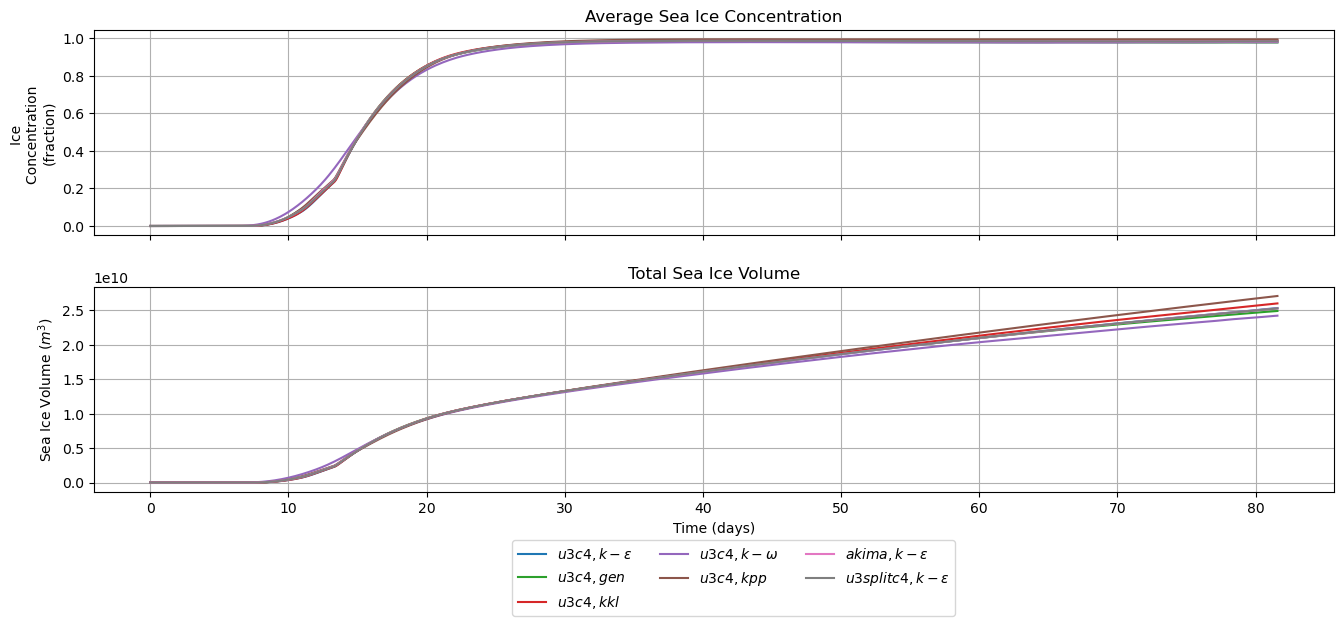

In [61]:
# Plot just sea ice conditions by themselves

# Make the figure
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot Sea ice concentration
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[0].plot(time_u3c4_keps[:980], ice_conc_u3c4_keps_reg1_avg[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[0].plot(time_u3c4_gen[:980], ice_conc_u3c4_gen_reg1_avg[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[0].plot(time_u3c4_kkl[:980], ice_conc_u3c4_kkl_reg1_avg[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[0].plot(time_u3c4_komega[:980], ice_conc_u3c4_komega_reg1_avg[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[0].plot(time_u3c4_kpp[:980], ice_conc_u3c4_kpp_reg1_avg[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[0].plot(time_akima_keps[:980], ice_conc_akima_keps_reg1_avg[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[2].plot(time_hsimt_keps[:980], ice_conc_hsimt_keps_reg1_avg[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[2].plot(time_mpdata_keps[:980], ice_conc_mpdata_keps_reg1_avg[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[0].plot(time_u3splitc4_keps[:980], ice_conc_u3splitc4_keps_reg1_avg[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[0].set_ylabel('Ice \nConcentration \n(fraction)')
ax[0].set_title(r'Average Sea Ice Concentration')

# Plot Sea ice volume
# --- Vertical Mixing Schemes ---
# U3C4 K-epsilon Ice
ax[1].plot(time_u3c4_keps[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[0], label=r'$u3c4,k-\epsilon$')
# U3C4 K-epsilon No ice
#ax[2].plot(time_u3c4_keps_no_ice[:980], ice_vol_u3c4_keps_reg1_tot[:980], color=mixing_colors_all[1], label=r'$\mathcal{M}_{phys,temp,no ice}$')
# U3C4 Gen
ax[1].plot(time_u3c4_gen[:980], ice_vol_u3c4_gen_reg1_tot[:980], color=mixing_colors_all[2], label=r'$u3c4,gen$')
# U3C4 kkl
ax[1].plot(time_u3c4_kkl[:980], ice_vol_u3c4_kkl_reg1_tot[:980], color=mixing_colors_all[3], label=r'$u3c4,kkl$')
# U3C4 k-omega
ax[1].plot(time_u3c4_komega[:980], ice_vol_u3c4_komega_reg1_tot[:980], color=mixing_colors_all[4], label=r'$u3c4,k-\omega$')
# U3C4 kpp
ax[1].plot(time_u3c4_kpp[:980], ice_vol_u3c4_kpp_reg1_tot[:980], color=mixing_colors_all[5], label=r'$u3c4,kpp$')
# --- Horizontal Advection Schemes ---
# akima k-epsilon
ax[1].plot(time_akima_keps[:980], ice_vol_akima_keps_reg1_tot[:980], color=mixing_colors_all[6], label=r'$akima,k-\epsilon$')
# hsimt k-epsilon
#ax[1].plot(time_hsimt_keps[:980], ice_vol_hsimt_keps_reg1_tot[:980], color=mixing_colors_all[7], label=r'$HSIMT,k-\epsilon$')
# mpdata k-epsilon
#ax[1].plot(time_mpdata_keps[:980], ice_vol_mpdata_keps_reg1_tot[:980], color=mixing_colors_all[8], label=r'$MPDATA,k-\epsilon$')
# U3splitC4 k-epsilon
ax[1].plot(time_u3splitc4_keps[:980], ice_vol_u3splitc4_keps_reg1_tot[:980], color=mixing_colors_all[9], label=r'$u3splitc4,k-\epsilon$')

# Label plot
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Sea Ice Volume ($m^{3}$)')
ax[1].set_title(r'Total Sea Ice Volume')

# Add legends
#ax[0].legend(ncols=3, bbox_to_anchor=(0.4, -0.1))
ax[0].set_xticklabels('')
ax[1].legend(ncols=3, bbox_to_anchor=(0.70, -0.2))
ax[0].grid()
ax[1].grid()

fig.subplots_adjust(hspace=0.25)

# Add vertical lines for days in snapshots


# ax[0].semilogy()
# ax[1].semilogy()

# Save the figure
#plt.savefig('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Figures/mphys_mnum_salt_temp_ice_vs_no_ice_500m_const_forc_u3c4_keps_001.png')

